In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Malgun Gothic'   # 윈도우 한글 폰트
plt.rcParams['axes.unicode_minus'] = False      # 마이너스 깨짐 방지


In [10]:
df_area = pd.read_csv("../../../data/processed/area.csv")
df_area.head()
# 이건 시각화 안 해도 될듯?

,SIDO,SIDO_NAME,SIGUNGU,SIGUNGU_NAME,AREA_NAME
0,11,서울특별시,11000,전체,서울특별시 전체
1,11,서울특별시,11110,종로구,서울특별시 종로구
2,11,서울특별시,11140,중구,서울특별시 중구
3,11,서울특별시,11170,용산구,서울특별시 용산구
4,11,서울특별시,11200,성동구,서울특별시 성동구


In [11]:
df_flood_area = pd.read_csv("../../../data/processed/flood_area.csv")
df_flood_area

,SIGUNGU,FLOOD_YEAR,FLOOD_MONTH,FLOOD_AREA
0,43111,2017,7,8420.8600
1,43111,2017,7,3860.0540
2,43111,2017,7,1686.6630
3,43111,2017,7,15485.9220
4,43111,2017,7,15076.9760
...,...,...,...,...
17958,46800,2021,7,41921.4000
17959,45730,2021,8,564.3333
17960,45730,2021,8,1132.0435
17961,44790,2022,8,708.8000


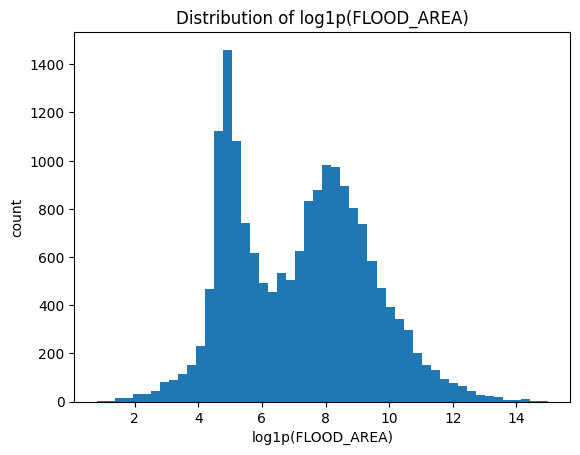

In [14]:
import numpy as np
import matplotlib.pyplot as plt

plt.hist(np.log1p(df_flood_area['FLOOD_AREA']), bins=50)
plt.title('Distribution of log1p(FLOOD_AREA)')
plt.xlabel('log1p(FLOOD_AREA)'); plt.ylabel('count')
plt.show()


In [ ]:
df_flooding_disaster = pd.read_csv("../../../data/processed/Flooding_Disaster.csv")
df_flooding_disaster

,FLOOD_YEAR,DAM_RAIN,DEAD,SIGUNGU,FLOOD_GRD
0,2024,300.0,0.0,41480,2.0
1,2016,150.0,0.0,52770,2.0
2,2016,150.0,0.0,52770,2.0
3,2016,150.0,0.0,52770,2.0
4,2016,150.0,0.0,52770,2.0
...,...,...,...,...,...
9254,2023,198.0,0.0,44760,2.0
9255,2018,198.0,0.0,46840,2.0
9256,2022,200.0,0.0,51730,2.0
9257,2023,198.0,0.0,52210,2.0


C:\Users\USER\AppData\Local\Temp\ipykernel_32496\1206514865.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([data.loc[data['FLOOD_GRD']==g, 'DAM_RAIN'] for g in sorted(data['FLOOD_GRD'].unique())],


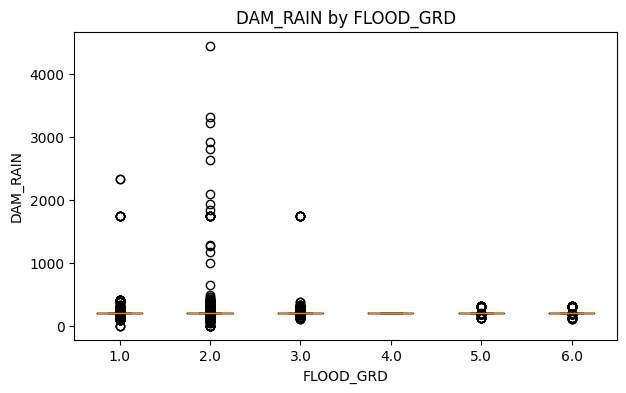

In [15]:
# 등급별 강수량 분포

import matplotlib.pyplot as plt

data = df_flooding_disaster.dropna(subset=['FLOOD_GRD','DAM_RAIN'])

plt.figure(figsize=(7,4))
plt.boxplot([data.loc[data['FLOOD_GRD']==g, 'DAM_RAIN'] for g in sorted(data['FLOOD_GRD'].unique())],
            labels=sorted(data['FLOOD_GRD'].unique()))
plt.title('DAM_RAIN by FLOOD_GRD')
plt.xlabel('FLOOD_GRD'); plt.ylabel('DAM_RAIN')
plt.show()


In [ ]:
df_riv = pd.read_csv("../../../data/processed/riv_pro_df.csv")
df_riv

,RIV_GRD,RIV_DIS_MIN,RIV_DIS_GRD,SIGUNGU
0,2,478.260258,3,51830
1,2,472.676208,3,51830
2,2,464.709738,3,51830
3,2,468.304507,3,51830
4,2,297.178959,4,51830
...,...,...,...,...
1462,2,229.527556,4,50110
1463,2,345.132782,3,50110
1464,2,452.014581,3,50110
1465,2,525.988454,3,50110


In [ ]:
df_weather = pd.read_csv("../../../data/processed/weather_rain_data.csv")
df_weather

,SIGUNGU,FLOOD_YEAR,FLOOD_MONTH,RAIN_TOTAL
0,51820,2016,1,6.6
1,51780,2016,1,0.9
2,41250,2016,1,1.3
3,41480,2016,1,1.0
4,51760,2016,1,2.6
...,...,...,...,...
14955,48270,2025,11,18.3
14956,48860,2025,11,23.4
14957,48310,2025,11,31.0
14958,48840,2025,11,39.2


C:\Users\USER\AppData\Local\Temp\ipykernel_32496\2933001604.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=grds, showfliers=False)


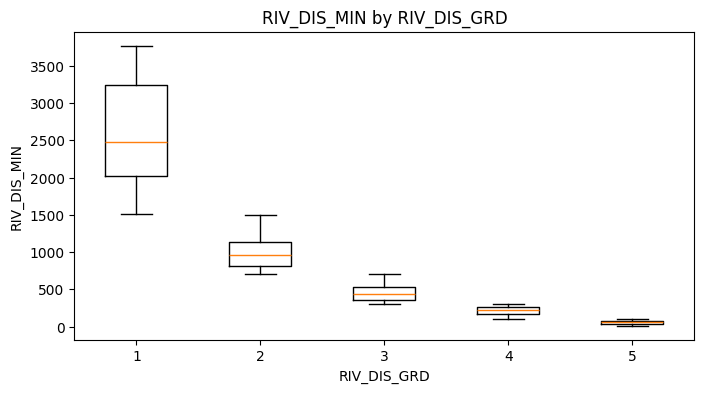

In [ ]:
grds = sorted(df_riv['RIV_DIS_GRD'].dropna().unique())

data = [df_riv.loc[df_riv['RIV_DIS_GRD']==g, 'RIV_DIS_MIN'].dropna() for g in grds]

plt.figure(figsize=(8,4))
plt.boxplot(data, labels=grds, showfliers=False)
plt.title('RIV_DIS_MIN by RIV_DIS_GRD')
plt.xlabel('RIV_DIS_GRD'); plt.ylabel('RIV_DIS_MIN')
plt.show()


# df_riv는 하천 관련 위험 특성(거리/등급) 을 담고 있어. 침수는 “물”이 핵심이라서 하천과의 거리(또는 하천 위험등급) 는 예측에서 강력한 후보 피처가 될 가능성이 큼.

# 그래서 시각화는 크게 3가지를 확인하려는 목적이 있어:

# 데이터 품질/분포 점검

# 값이 한쪽으로 치우쳤는지, 이상치가 많은지, 특정 등급에만 몰려 있는지
# → 전처리/모델 선택/스케일링에 직접 영향

# 피처의 의미가 논리적으로 맞는지 검증(상식 검증)

# 거리 등급이 높을수록 실제 거리가 멀어야 “등급 체계가 정상”
# → 잘못 만들었거나 단위/계산 오류면 모델이 망가짐

# 지역 편향(커버리지) 확인

# 특정 시군구에만 데이터가 과하게 많거나 적으면
# → 학습 데이터가 지역에 치우쳐서 모델이 한쪽으로만 학습될 수 있음



In [ ]:
pump_df = pd.read_csv("../../../data/processed/solid_pump_data.csv")
pump_df

,SIGUNGU,DRAINAGE_GRD,PUMP_CNT
0,51150,1,2
1,51170,1,1
2,41820,1,2
3,41281,2,5
4,41287,4,3
...,...,...,...
77,44230,4,7
78,44200,2,5
79,44800,2,3
80,43800,1,1


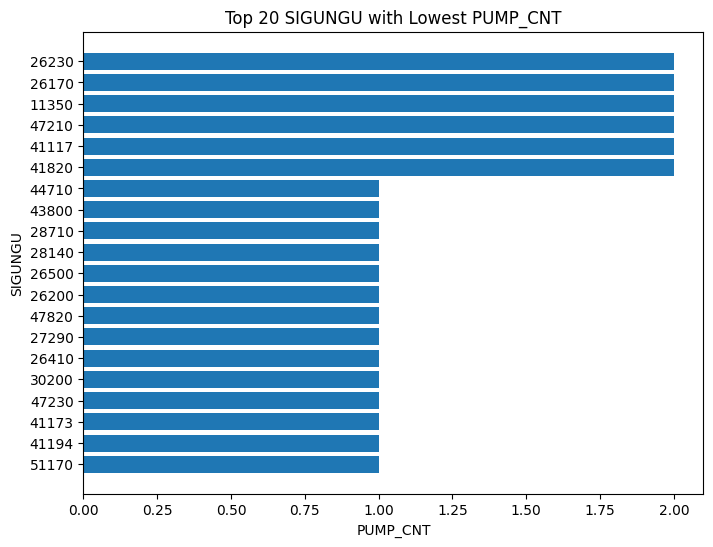

In [17]:
top_low = pump_df.sort_values('PUMP_CNT', ascending=True).head(20)

plt.figure(figsize=(8,6))
plt.barh(top_low['SIGUNGU'].astype(str), top_low['PUMP_CNT'])
plt.title('Top 20 SIGUNGU with Lowest PUMP_CNT')
plt.xlabel('PUMP_CNT'); plt.ylabel('SIGUNGU')
plt.show()


Text(0, 0.5, 'Flood Area')

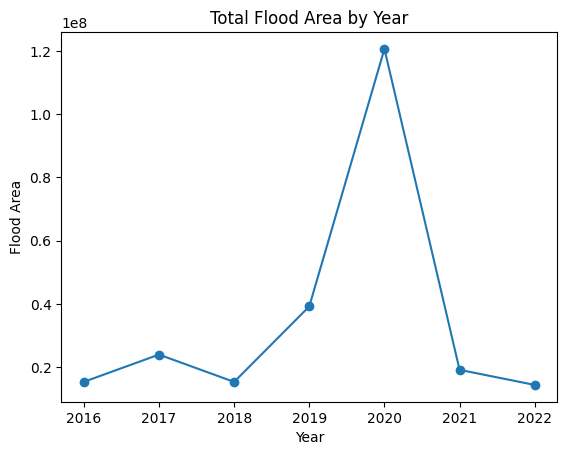

In [18]:
tmp = df_flood_area.copy()

year_sum = tmp.groupby('FLOOD_YEAR', as_index=False)['FLOOD_AREA'].sum()

ax = year_sum.plot(x='FLOOD_YEAR', y='FLOOD_AREA', kind='line', marker='o', legend=False)
ax.set_title('Total Flood Area by Year')
ax.set_xlabel('Year'); ax.set_ylabel('Flood Area')


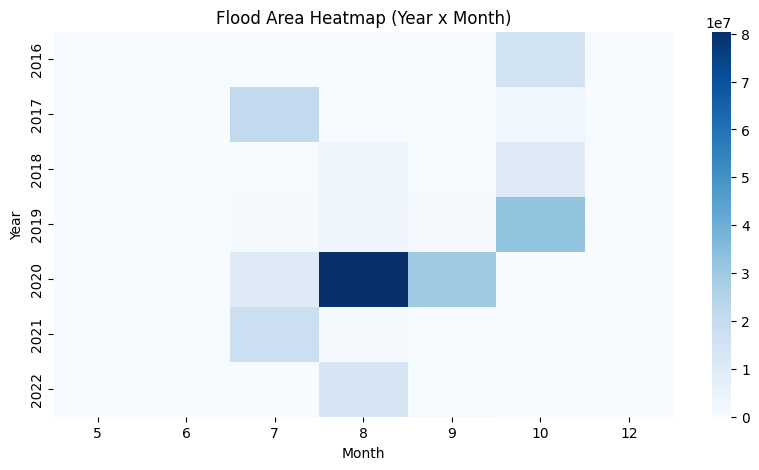

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = (df_flood_area
         .groupby(['FLOOD_YEAR','FLOOD_MONTH'])['FLOOD_AREA']
         .sum()
         .unstack(fill_value=0)
        )

plt.figure(figsize=(10,5))
sns.heatmap(pivot, cmap='Blues')  # 색은 취향대로
plt.title('Flood Area Heatmap (Year x Month)')
plt.xlabel('Month'); plt.ylabel('Year')
plt.show()


Text(0, 0.5, 'Mean DAM_RAIN')

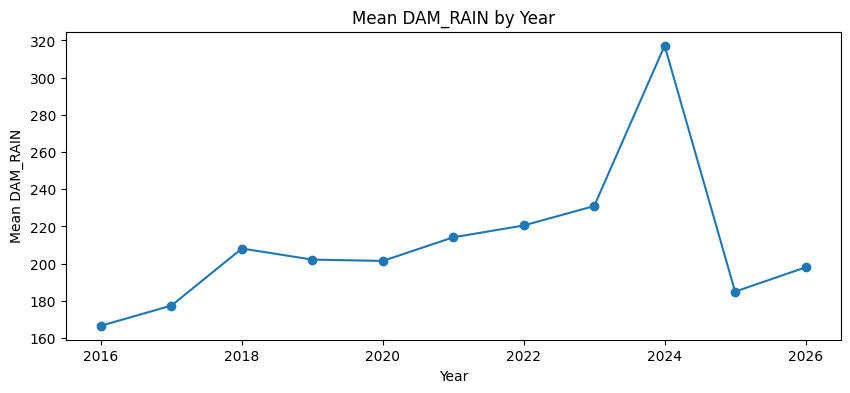

In [21]:
year_stat = df_flooding_disaster.groupby('FLOOD_YEAR').agg(
    mean_rain=('DAM_RAIN','mean'),
    mean_grd=('FLOOD_GRD','mean'),
    sum_dead=('DEAD','sum')
).reset_index()

ax = year_stat.plot(x='FLOOD_YEAR', y='mean_rain', kind='line', marker='o', figsize=(10,4), legend=False)
ax.set_title('Mean DAM_RAIN by Year')
ax.set_xlabel('Year'); ax.set_ylabel('Mean DAM_RAIN')


Text(0.5, 0, 'Count')

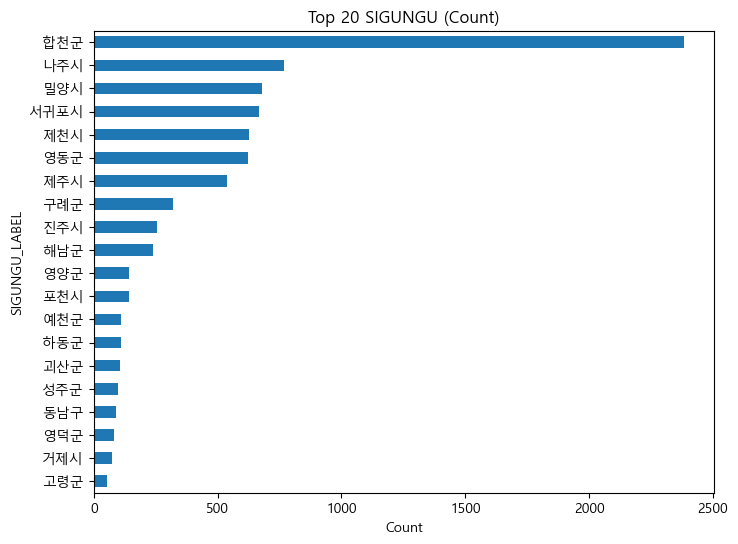

In [27]:
import pandas as pd

# 1) area.csv 로드 (SIGUNGU ↔ SIGUNGU_NAME 매핑용)
area_df = pd.read_csv("../../../data/processed/area.csv")  # 너희 경로로 수정

# 2) 코드 타입 통일 (매우 중요: int/str 섞이면 매핑 안 됨)
df_flooding_disaster['SIGUNGU'] = df_flooding_disaster['SIGUNGU'].astype(str)
area_df['SIGUNGU'] = area_df['SIGUNGU'].astype(str)

# 3) 집계(top20) 만들기
top = (df_flooding_disaster.groupby('SIGUNGU')
       .agg(cnt=('FLOOD_GRD','size'),
            mean_grd=('FLOOD_GRD','mean'),
            sum_rain=('DAM_RAIN','sum'))
       .sort_values('cnt', ascending=False)
       .head(20)
       .reset_index()
)

# 4) SIGUNGU_NAME 붙이기 (merge)
top = top.merge(area_df[['SIGUNGU', 'SIGUNGU_NAME']], on='SIGUNGU', how='left')

# 5) 이름이 없는 경우 대비: 이름 없으면 코드로 대체
top['SIGUNGU_LABEL'] = top['SIGUNGU_NAME'].fillna(top['SIGUNGU'])

# 6) plot (y축을 지역명으로)
top_plot = top.set_index('SIGUNGU_LABEL').sort_values('cnt')

ax = top_plot['cnt'].plot(kind='barh', figsize=(8, 6))
ax.set_title('Top 20 SIGUNGU (Count)')
ax.set_xlabel('Count')
